# Stimulus encoding by phase and amplitude in fronto-parietal LFPs

This notebook reproduces **Figure 6** and **Figure 7** of the paper. We start from raw
local field potential (LFP) recordings of monkey *betty* during a working-memory
task (GrayLab dataset) and quantify how much information about the presented
stimulus is carried by:

1. the **amplitude** ($A$) and **phase difference** ($\Delta\theta$) of pairs of
   recording sites (Figure 6, single-pair analysis), and
2. the **higher-order** combination of two such amplitude edges (Figure 7,
   multi-pair / synergy analysis).

The pipeline is:

1. **Load** the raw LFP traces, restrict to good behavioral trials and crop a
   $[-0.4, +1.7]\,\text{s}$ window around cue onset.
2. **Decompose** the signal in time-frequency with a multitaper Morlet
   decomposition ($5\!-\!35\,\text{Hz}$).
3. **Compute** for each pair of channels the cross-spectrum and extract its
   amplitude $A$ and phase difference $\Delta\theta$.
4. **Estimate** mutual information (MI) between these features and the per-trial
   stimulus label using a Gaussian-copula MI (GCMI) estimator.
5. **Combine** the marginal and joint MI through a partial information
   decomposition (PID) into *redundant*, *unique* and *synergistic* components.
6. **Test** significance with a stimulus-label permutation null and
   cluster-mass correction.

In [62]:
# Make the parent directory importable so we can pick up local helpers
# (e.g. `session`, `plot`) that live alongside the notebooks folder.
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

In [63]:
# Scientific stack
import jax
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import scipy
import xarray as xr

# Information-theoretic estimators and group-level statistics from frites
from frites.core import gcmi_model_nd_cd
from frites.workflow import WfStats

# Higher-order interaction estimator
from hoi.core import get_mi

# MNE utilities for filtering and time-frequency decomposition (multitaper / Morlet)
from mne.filter import filter_data
from mne.time_frequency import tfr_array_morlet, tfr_array_multitaper

# Local helpers and progress bar
from session import session_info
from tqdm import tqdm

In [64]:
# Global font sizes used throughout all figures in this notebook.
# Set once via rcParams so individual plotting calls stay clean.
SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)        # default text size
plt.rc("axes", titlesize=SMALL_SIZE)   # axes title font
plt.rc("axes", labelsize=SMALL_SIZE)   # x/y axis labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # x tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # y tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend text
plt.rc("figure", titlesize=BIGGER_SIZE)  # suptitle

## Helper functions

The cells below define small utilities used throughout the notebook:

- `trial_to_string` – format a trial number as a zero-padded 4-digit string,
  matching the GrayLab `betty<session>01.NNNN.mat` filename convention.
- `shuffle_along_axis` – independent permutation of an array along one axis,
  preserving per-slice marginals while breaking any structural ordering.
- `create_generalized_surrogates` – build *semi-generalized* surrogate signal
  pairs by mixing trials **and** channels. Used as a more conservative null
  than a plain trial shuffle when the connectivity structure itself must be
  destroyed.

In [65]:
def trial_to_string(trial_no, n_max):
    """Zero-pad an integer trial number to ``n_max`` digits.

    Used to build LFP filenames that follow the ``betty<session>01.NNNN.mat``
    naming convention on disk.
    """
    trial_no = str(trial_no)
    n = len(trial_no)
    return (n_max - n) * "0" + trial_no

In [66]:
def shuffle_along_axis(a, axis):
    """Independently permute the values of ``a`` along ``axis``.

    Each 1-D slice along the given axis gets its own random permutation
    (different from the other slices), which preserves the marginal
    distribution per slice while breaking any temporal/structural ordering.
    """
    idx = np.random.rand(*a.shape).argsort(axis=axis)
    return np.take_along_axis(a, idx, axis=axis)


def create_generalized_surrogates(X, n_boot=10000):
    """Build semi-generalized surrogates by mixing trials AND channels.

    For each of ``n_boot`` draws we pick:
      - a random pair of distinct trials (without replacement),
      - a random pair of distinct channels (without replacement),
    and stack their LFP traces. The pair's effective "match-on" time is
    aligned to the earliest of the two trials so downstream epoching is safe.

    Parameters
    ----------
    X : xarray.DataArray
        Shape (T, R, N) with dims (trials, roi, times). Must carry the
        ``t_match_on``, ``t_cue_on`` attrs and the ``fsample`` sampling rate.
    n_boot : int
        Number of surrogate pairs to generate.

    Returns
    -------
    data_surr : ndarray, shape (n_boot, 2, N)
        Stacked surrogate signal pairs.
    onsets : ndarray, shape (n_boot,)
        Per-pair earliest match-on time, in seconds relative to cue onset.
    """
    T, R, N = X.shape  # T trials, R channels, N samples

    # Per-trial match-on time relative to cue onset, in seconds (rounded).
    # NOTE: relies on the outer-scope `data` for its attributes.
    t_match_on = (data.attrs["t_match_on"] - data.attrs["t_cue_on"]) / data.fsample
    t_match_on = np.round(t_match_on, 1)

    X = X.values

    # Sample n_boot random pairs of distinct trials (without replacement within a pair)
    count = 0
    trials_surr = []
    while count < n_boot:
        out = np.random.choice(
            range(T),
            size=2,
            replace=False,
        )
        trials_surr += [out]
        count = count + 1
    trials_surr = np.stack(trials_surr)

    # Sample n_boot random pairs of distinct channels
    count = 0
    channels_surr = []
    while count < n_boot:
        out = np.random.choice(
            range(R),
            size=2,
            replace=False,
        )
        channels_surr += [out]
        count = count + 1
    channels_surr = np.stack(channels_surr)

    # Build the surrogate signal pairs by combining the sampled trial/channel pairs
    data_surr = []
    for c_i, c_j, trial_i, trial_j in np.concatenate(
        (channels_surr, trials_surr), axis=1
    ):
        x = X[trial_i, c_i]
        y = X[trial_j, c_j]  # [..., ::-1]  # reversal disabled
        data_surr += [np.stack((x, y))]

    # Use the earliest match-on time within each pair so the surrogate window
    # never extends past either real trial's stimulus event.
    onsets = []
    for t1, t2 in trials_surr:
        onsets += [min(t_match_on[t1], t_match_on[t2])]
    onsets = np.stack(onsets)

    return np.stack(data_surr), onsets

## Load the recording session

We pick a single session of monkey *betty* (`090615`) from the GrayLab LFP
database. Each session ships with two MATLAB files:

- `trial_info.mat` – per-trial behavioral and event-timing information
  (rule, match image / match location, cue and match onsets, quality flags),
- `recording_info.mat` – channel-level metadata (sampling rate, ROI labels).

The raw LFP itself is split across one MATLAB file per trial
(`betty<session>01.NNNN.mat`).

Trials are filtered to keep only those that satisfy **all three** quality
criteria — a valid behavioral response, a stable recording, and the upstream
"good_trials" flag — yielding the working set used for everything that follows.
For each retained trial we also build a `stim` label that picks the
task-relevant feature (image identity in the rule-1 task, target location in the
rule-0 task), since this is the variable whose mutual information we will
estimate.

Finally we crop each trial to the analysis window
$[-0.4, +1.7]\,\text{s}$ around cue onset, sampled at the LFP rate.

In [67]:
# Recording session to analyze. Pick a different ID (or loop with
# `sessions[index]` once `sessions` is defined) to run on another session.
session = "090615"

# Root of the GrayLab LFP database for monkey "betty".
data_dir = "/home/INT/brovelli.a/envau/work/brainets/data/db_lfp/lfp_graylab/betty/"

In [68]:
# Per-session folder containing trial_info.mat, recording_info.mat and the
# per-trial LFP .mat files.
root = f"{data_dir}/{session}/session01/"

In [69]:
# Load per-trial behavioral / event-timing metadata from MATLAB.
# `simplify_cells=True` flattens MATLAB structs to plain Python dicts/arrays.
trial_info = {}
scipy.io.loadmat(
    os.path.join(root, "trial_info.mat"), simplify_cells=True, mdict=trial_info
)
trial_info = trial_info["trial_info"]

In [70]:
# Load recording-level metadata (sampling rate, channel count, ROI labels, ...).
recording_info = {}
scipy.io.loadmat(
    os.path.join(root, "recording_info.mat"), simplify_cells=True, mdict=recording_info
)
recording_info = recording_info["recording_info"]

In [71]:
# Keep only trials that satisfy ALL of the following criteria:
#   - behavioral_response: monkey produced a valid response,
#   - stable_trials: recording was stable (no major artifacts),
#   - good_trials: passes upstream quality control.
# The element-wise product acts as a logical AND on 0/1 masks.
task_trials = np.where(
    trial_info["behavioral_response"]
    * trial_info["stable_trials"]
    * trial_info["good_trials"]
)[0]

In [72]:
# Build the per-trial stimulus label `stim`.
# Two task rules are interleaved within a session:
#   rule == 1 -> identity-matching task: the relevant feature is `match_image`.
#   rule != 1 -> location-matching task: the relevant feature is `match_location`.
# We pick whichever feature was task-relevant for that trial so that downstream
# information-theoretic measures use the correct stimulus label per trial.
stim = []

for trial in task_trials:

    if trial_info["rule"][trial] == 1:
        stim.append(trial_info["match_image"][trial])
    else:
        stim.append(trial_info["match_location"][trial])

In [73]:
# Per-trial epoch window: 400 ms before cue onset to 1700 ms after, sampled
# at the LFP rate. Used both as the time axis of `data` and to compute the
# integer indices into each raw .mat file below.
time_array = np.arange(-0.4, 1.7, 1 / recording_info["lfp_sampleingrate"])

In [74]:
# Pre-compute output array shape: (trials x channels/ROIs x time samples).
n_trials, n_channels, n_times = (
    len(task_trials),
    recording_info["channel_count"],
    len(time_array),
)

In [75]:
# Allocate the (trials, channels, times) LFP tensor.
data = np.empty((n_trials, n_channels, n_times))

# Loop over selected trials, load each raw LFP file and crop the epoch window
# defined by `time_array` around `sample_on` (cue onset).
i = 0
for trial in tqdm(task_trials):

    # Trial files are 1-indexed on disk and zero-padded to 4 digits.
    lfp_data = scipy.io.loadmat(
        os.path.join(root, f"betty{session}01.{trial_to_string(trial + 1, 4)}.mat")
    )["lfp_data"]

    # Sample indices for this trial's epoch (relative to file start), derived
    # from cue onset + the [time_array.min(), time_array.max()] window.
    indb = int(
        trial_info["sample_on"][trial]
        + recording_info["lfp_sampleingrate"] * time_array.min()
    )
    inde = int(
        trial_info["sample_on"][trial]
        + recording_info["lfp_sampleingrate"] * time_array.max()
    )
    # Store the (n_channels, n_times) slice for this trial.
    data[i, ...] = lfp_data[:, indb : inde + 1]

    i = i + 1

100%|██████████| 993/993 [00:11<00:00, 88.89it/s]


## Wrap as an `xarray.DataArray`

We re-package the raw `(trials, channels, times)` NumPy array into an
`xarray.DataArray`. This lets us:

- index by name (`data.sel(roi="PE")`, `data.isel(times=slice(...))`)
  rather than by positional axis number,
- carry the per-trial **stimulus label** as the `trials` coordinate, so
  computing $I(\text{feature};\text{stimulus})$ becomes a one-liner,
- attach the event timings (`t_cue_on`, `t_match_on`) and the sampling rate
  (`fsample`) as `attrs`, so downstream surrogate generation has all it needs
  without re-loading the MATLAB metadata.

The cell below also produces a quick stacked-trace sanity check to confirm
that the loaded LFPs look reasonable.

In [76]:
# Wrap the raw NumPy array as an xarray.DataArray so we can index by name
# (trials/roi/times) and carry along trial / event / sampling-rate metadata.
# The trial coord is the per-trial stimulus label, which makes it trivial
# to compute mutual information about the stimulus later.
data = xr.DataArray(
    data,
    dims=("trials", "roi", "times"),
    coords=(
        # trial_info["match_image"][task_trials],  # alternative: image label only
        stim,
        recording_info["area"],
        time_array,
    ),
    attrs={
        "t_match_on": trial_info["match_on"],   # match-on time (samples) per trial
        "t_cue_on": trial_info["sample_on"],    # cue-on time (samples) per trial
        "fsample": recording_info["lfp_sampleingrate"],  # LFP sampling rate (Hz)
    },
)

(np.float64(-0.5),
 np.float64(1.7),
 np.float64(-4.561347220428129),
 np.float64(18.97876915494901))

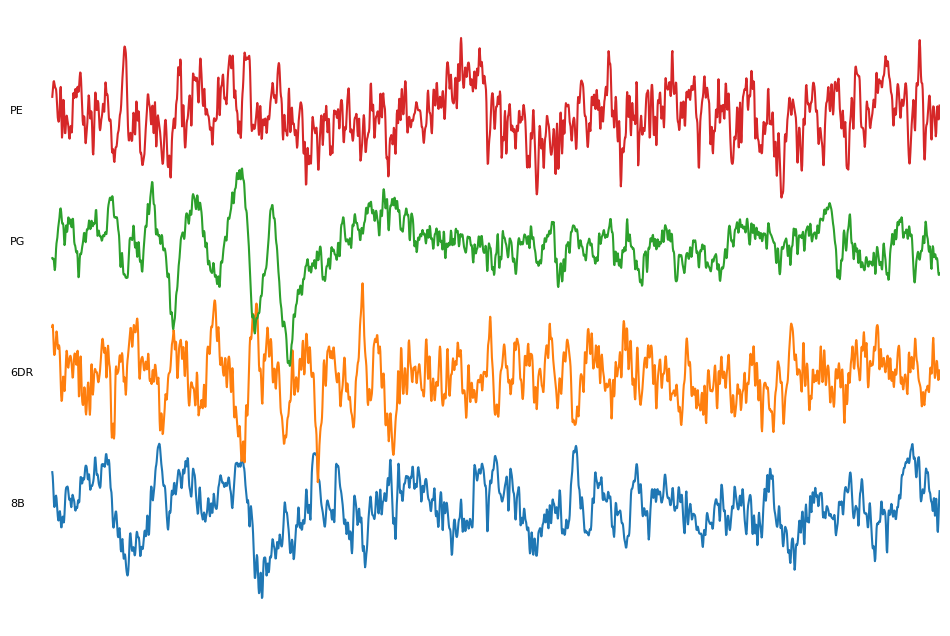

In [77]:
# Quick sanity check: stack of z-scored single-trial LFPs across ROIs for trial 0.
# Each ROI is offset vertically by 5 standardized units so traces don't overlap.
plt.figure(figsize=(12, 8))

# Per-channel z-score along time.
zdata = (data - data.mean("times")) / data.std("times")

for i in range(data.sizes["roi"]):
    plt.plot(data.times, zdata[0, i] + (i * 5))
    plt.text(-0.5, (i * 5), zdata.roi.values[i])  # ROI label on the left

plt.xlim(-0.5, 1.7)
plt.axis("off")

## Stimulus-related coherence (SCR)

For every channel pair $(i, j)$ we compute the cross-spectrum

$$
z_{ij}(f, t) = \langle W_i(f, t)\, W_j^{*}(f, t) \rangle_{\text{tapers}}
$$

and decompose it into two real-valued features:

- amplitude: $A_{ij}(f, t) = |z_{ij}(f, t)|$
- phase difference: $\Delta\theta_{ij}(f, t) = \big|\,(\arg z_{ij} + \pi) \bmod 2\pi - \pi\,\big|$

(folded into $[0, \pi]$ to remove a sign ambiguity that does not carry
information about the stimulus).

We then estimate the **mutual information** between these features and the
discrete stimulus label $Y$ using the Gaussian-copula MI estimator
(`gcmi_model_nd_cd`, with `gcrn=True` to rank-normalize each marginal):

- $I[A_{ij}; Y]$ — marginal MI carried by amplitude (`I_S_R1`),
- $I[\Delta\theta_{ij}; Y]$ — marginal MI carried by phase difference
  (`I_S_R2`),
- $I[A_{ij}, \Delta\theta_{ij}; Y]$ — joint MI carried by the bivariate
  $(A, \Delta\theta)$ (`I_S_R1_R2`).

Significance is assessed by a **stimulus-label permutation test**: the
stimulus vector is shuffled $1000$ times to build a null distribution of
$I[A, \Delta\theta; Y]$ at every $(f, t)$ pixel, and a cluster-mass
correction (frites' `WfStats` with `mcp="cluster"`) controls the
family-wise error rate over the time-frequency map.

In [78]:
# Optional debug knob: subset trials to make the rest of the notebook run faster.
# Left commented out so the published figures use the full dataset.
# data = data[:500]

In [79]:
# Time-frequency decomposition.
# 31 frequencies linearly spaced from 5 to 35 Hz cover theta/alpha/beta bands.
freqs = np.linspace(5., 35, 31)

# Multitaper Morlet-style decomposition.
#   - n_cycles=freqs/2: scale the wavelet length so the trade-off between
#     time and frequency resolution is constant across the band.
#   - decim=20: keep 1 time sample out of 20 (50 Hz output rate at 1 kHz LFP)
#     to keep memory manageable while still resolving slow modulations.
#   - time_bandwidth=5: number of tapers ~ 2*TW - 1, here ~9 tapers.
#   - output="complex": keep the complex coefficients so we can build both
#     amplitude (|W|) and phase (arg W) downstream.
W = tfr_array_multitaper(
    data,
    recording_info["lfp_sampleingrate"],
    freqs,
    n_cycles=freqs / 2,
    decim=20,
    time_bandwidth=5,
    output="complex",
    verbose=True,
)

[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:   11.2s finished


In [80]:
# All unordered pairs of channels (upper triangle, no self-pairs).
# x_s and x_t are aligned arrays of source/target ROI indices.
x_s, x_t = np.triu_indices(data.sizes["roi"], 1)

# Cross-spectrum per pair, averaged over tapers (axis 2 of W).
# z is complex-valued: |z| ~ pair amplitude, angle(z) ~ phase difference.
z = (W[:, x_s] * np.conj(W[:, x_t])).mean(2)

# Decompose into the two scalar features used downstream:
#   A    : amplitude of the cross-spectrum,
#   dphi : phase difference, wrapped into [0, pi] (sign-collapsed).
A = np.abs(z)
dphi = np.angle(z)
dphi = np.abs((dphi + np.pi) % (2 * np.pi) - np.pi)

# Move the trial axis to the back so the leading axes are (pair, freq, time),
# which is what gcmi_model_nd_cd expects with `traxis=-1` (its default).
A = A.transpose(1, 2, 3, 0)
dphi = dphi.transpose(1, 2, 3, 0)

# Bivariate (A, dphi) tensor used to compute the joint MI I[A, dphi; stim].
mv = np.stack((A, dphi))

In [81]:
# Marginal MI between cross-spectrum amplitude and the (discrete) stimulus.
# `gcrn=True` applies a Gaussian copula rank-normalization to the continuous
# variable, which makes the GCMI estimator robust to non-Gaussian marginals.
# The `[None]` adds a singleton mvaxis so A is treated as a 1-D continuous variable.
I_S_R1 = gcmi_model_nd_cd(A[None], np.asarray(data.trials.values), gcrn=True)[0]

In [82]:
# Marginal MI between phase-difference and the stimulus (same setup as I_S_R1).
I_S_R2 = gcmi_model_nd_cd(dphi[None], np.asarray(data.trials.values), gcrn=True)[0]

In [83]:
# Joint MI between the bivariate (A, dphi) and the stimulus.
# `mvaxis=0` says: the leading axis of `mv` enumerates the components of the
# multivariate continuous variable (here: 0 -> A, 1 -> dphi).
I_S_R1_R2 = gcmi_model_nd_cd(mv, np.asarray(data.trials.values), mvaxis=0, gcrn=True)

In [84]:
from joblib import Parallel, delayed


def compute_shuffle(mv):
    """Return one MI estimate computed with a permuted stimulus label.

    Permuting only the label vector (not the data) breaks the data-stimulus
    association while leaving the data's joint structure intact -- this is
    the textbook null distribution for stimulus encoding.
    """
    return gcmi_model_nd_cd(
        mv, np.random.permutation(data.trials.values), mvaxis=0, gcrn=True
    )

In [85]:
# Build a 1000-sample null distribution of I[A, dphi; stim] under the
# stimulus-label permutation null. n_jobs=-1 uses every available core.
I_S_R1_R2_shuffle = Parallel(n_jobs=-1)(
    delayed(compute_shuffle)(mv) for n in tqdm(range(1000))
)

100%|██████████| 1000/1000 [01:23<00:00, 11.92it/s]


In [86]:
# Reshape effect (x) and null (y) tensors per channel pair so they fit
# WfStats's expected layout: list of arrays with shape (subjects, freq, time)
# for `x` and (perm, subjects, freq, time) for `y`. We have one "subject"
# (this single session), so we add a leading length-1 axis with `[None]`.
x = [np.asarray(I_S_R1_R2[i][None]) for i in range(len(x_s))]
y = [np.stack(I_S_R1_R2_shuffle)[:, i][:, None] for i in range(len(x_s))]

In [87]:
# Cluster-corrected non-parametric p-values from the null distribution.
#   inference="ffx" : fixed-effect (single-session here, so no random subject term)
#   mcp="cluster"   : multiple-comparison correction by cluster-mass statistics
wf = WfStats()

p, t = wf.fit(
    x,
    y,
    inference="ffx",
    mcp="cluster",
)

p = p.squeeze()  # drop the singleton subject axis

# Smallest corrected p-value across the time-frequency map -- a quick sanity
# check that some pixel survives correction.
p.min()

Definition of a non-parametric statistical workflow
    Fixed-effect inference (FFX)
    Cluster forming threshold (tail=1; alpha=0.05; tfce=None)
    Inference at cluster-level
    Cluster detection (threshold=0.008787394936415708; tail=1)


np.float64(0.001)

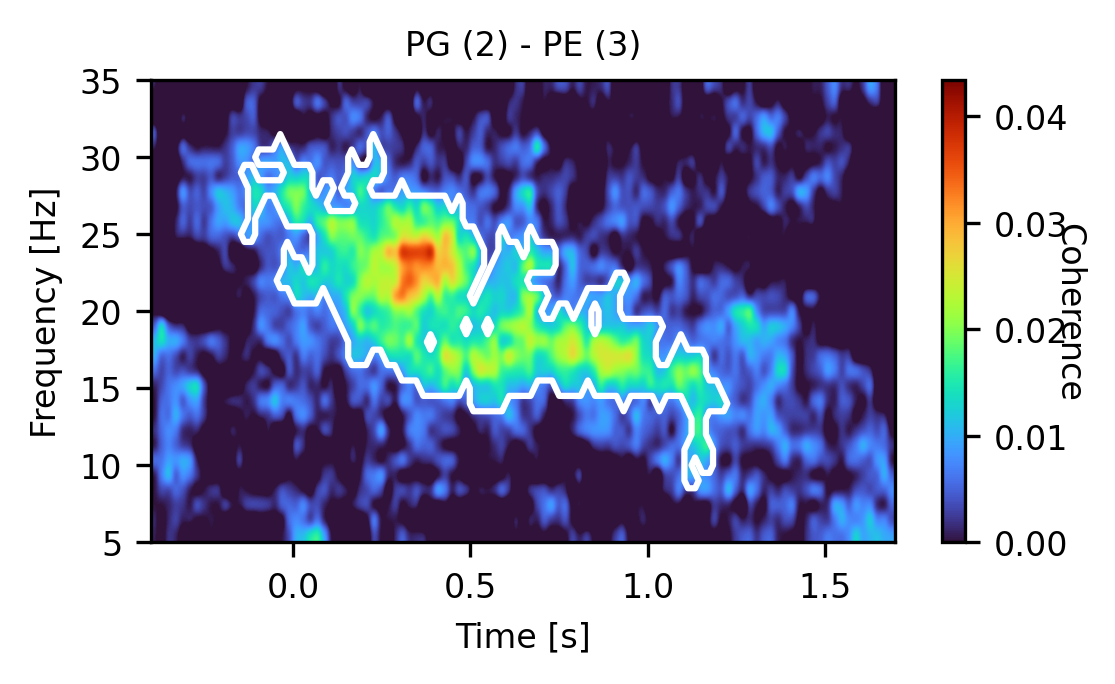

In [88]:
# Quick per-pair browser: one figure per (i, j) channel pair showing the joint
# I[A, dphi; stim] map with significant pixels (cluster p<=0.05) outlined in white.
# Reuses figure num=1 to avoid leaking many open figures into the kernel.
fig = plt.figure(num=1, clear=True, figsize=(4, 2), dpi=300)

pos = 0  # running index over channel pairs (matches x_s/x_t order)

for i, j in zip(x_s, x_t):

    fig = plt.figure(num=1, clear=True)

    # MI map for this pair: time on x, frequency on y.
    plt.imshow(
        I_S_R1_R2[pos],
        aspect="auto",
        origin="lower",
        cmap="turbo",
        extent=[time_array.min(), time_array.max(), freqs[0], freqs[-1]],
        vmin=0,
        interpolation="gaussian",
        vmax=I_S_R1_R2[pos].max(),
    )
    cbar = plt.colorbar()

    plt.title(f"{data.roi.values[i]} ({i}) - {data.roi.values[j]} ({j})")

    cbar.set_label("Coherence", rotation=270)
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")

    # White contour around the cluster-corrected p<=0.05 region.
    plt.contour(
        (p[..., pos] <= 0.05),
        levels=[0.5],
        colors="w",
        extent=[time_array.min(), time_array.max(), freqs[0], freqs[-1]],
    )

    pos = pos + 1

In [89]:
# Partial Information Decomposition (PID) of I[A, dphi; stim]:
#   red : redundancy  = min(I[A;stim], I[dphi;stim])  (Williams & Beer minimum-MI)
#   syn : synergy     = I[A,dphi;stim] - max(I[A;stim], I[dphi;stim])
# These are the standard "redundant" and "synergistic" components used in the figures.
red = np.minimum(I_S_R1, I_S_R2)
syn = I_S_R1_R2 - np.maximum(I_S_R2, I_S_R1)

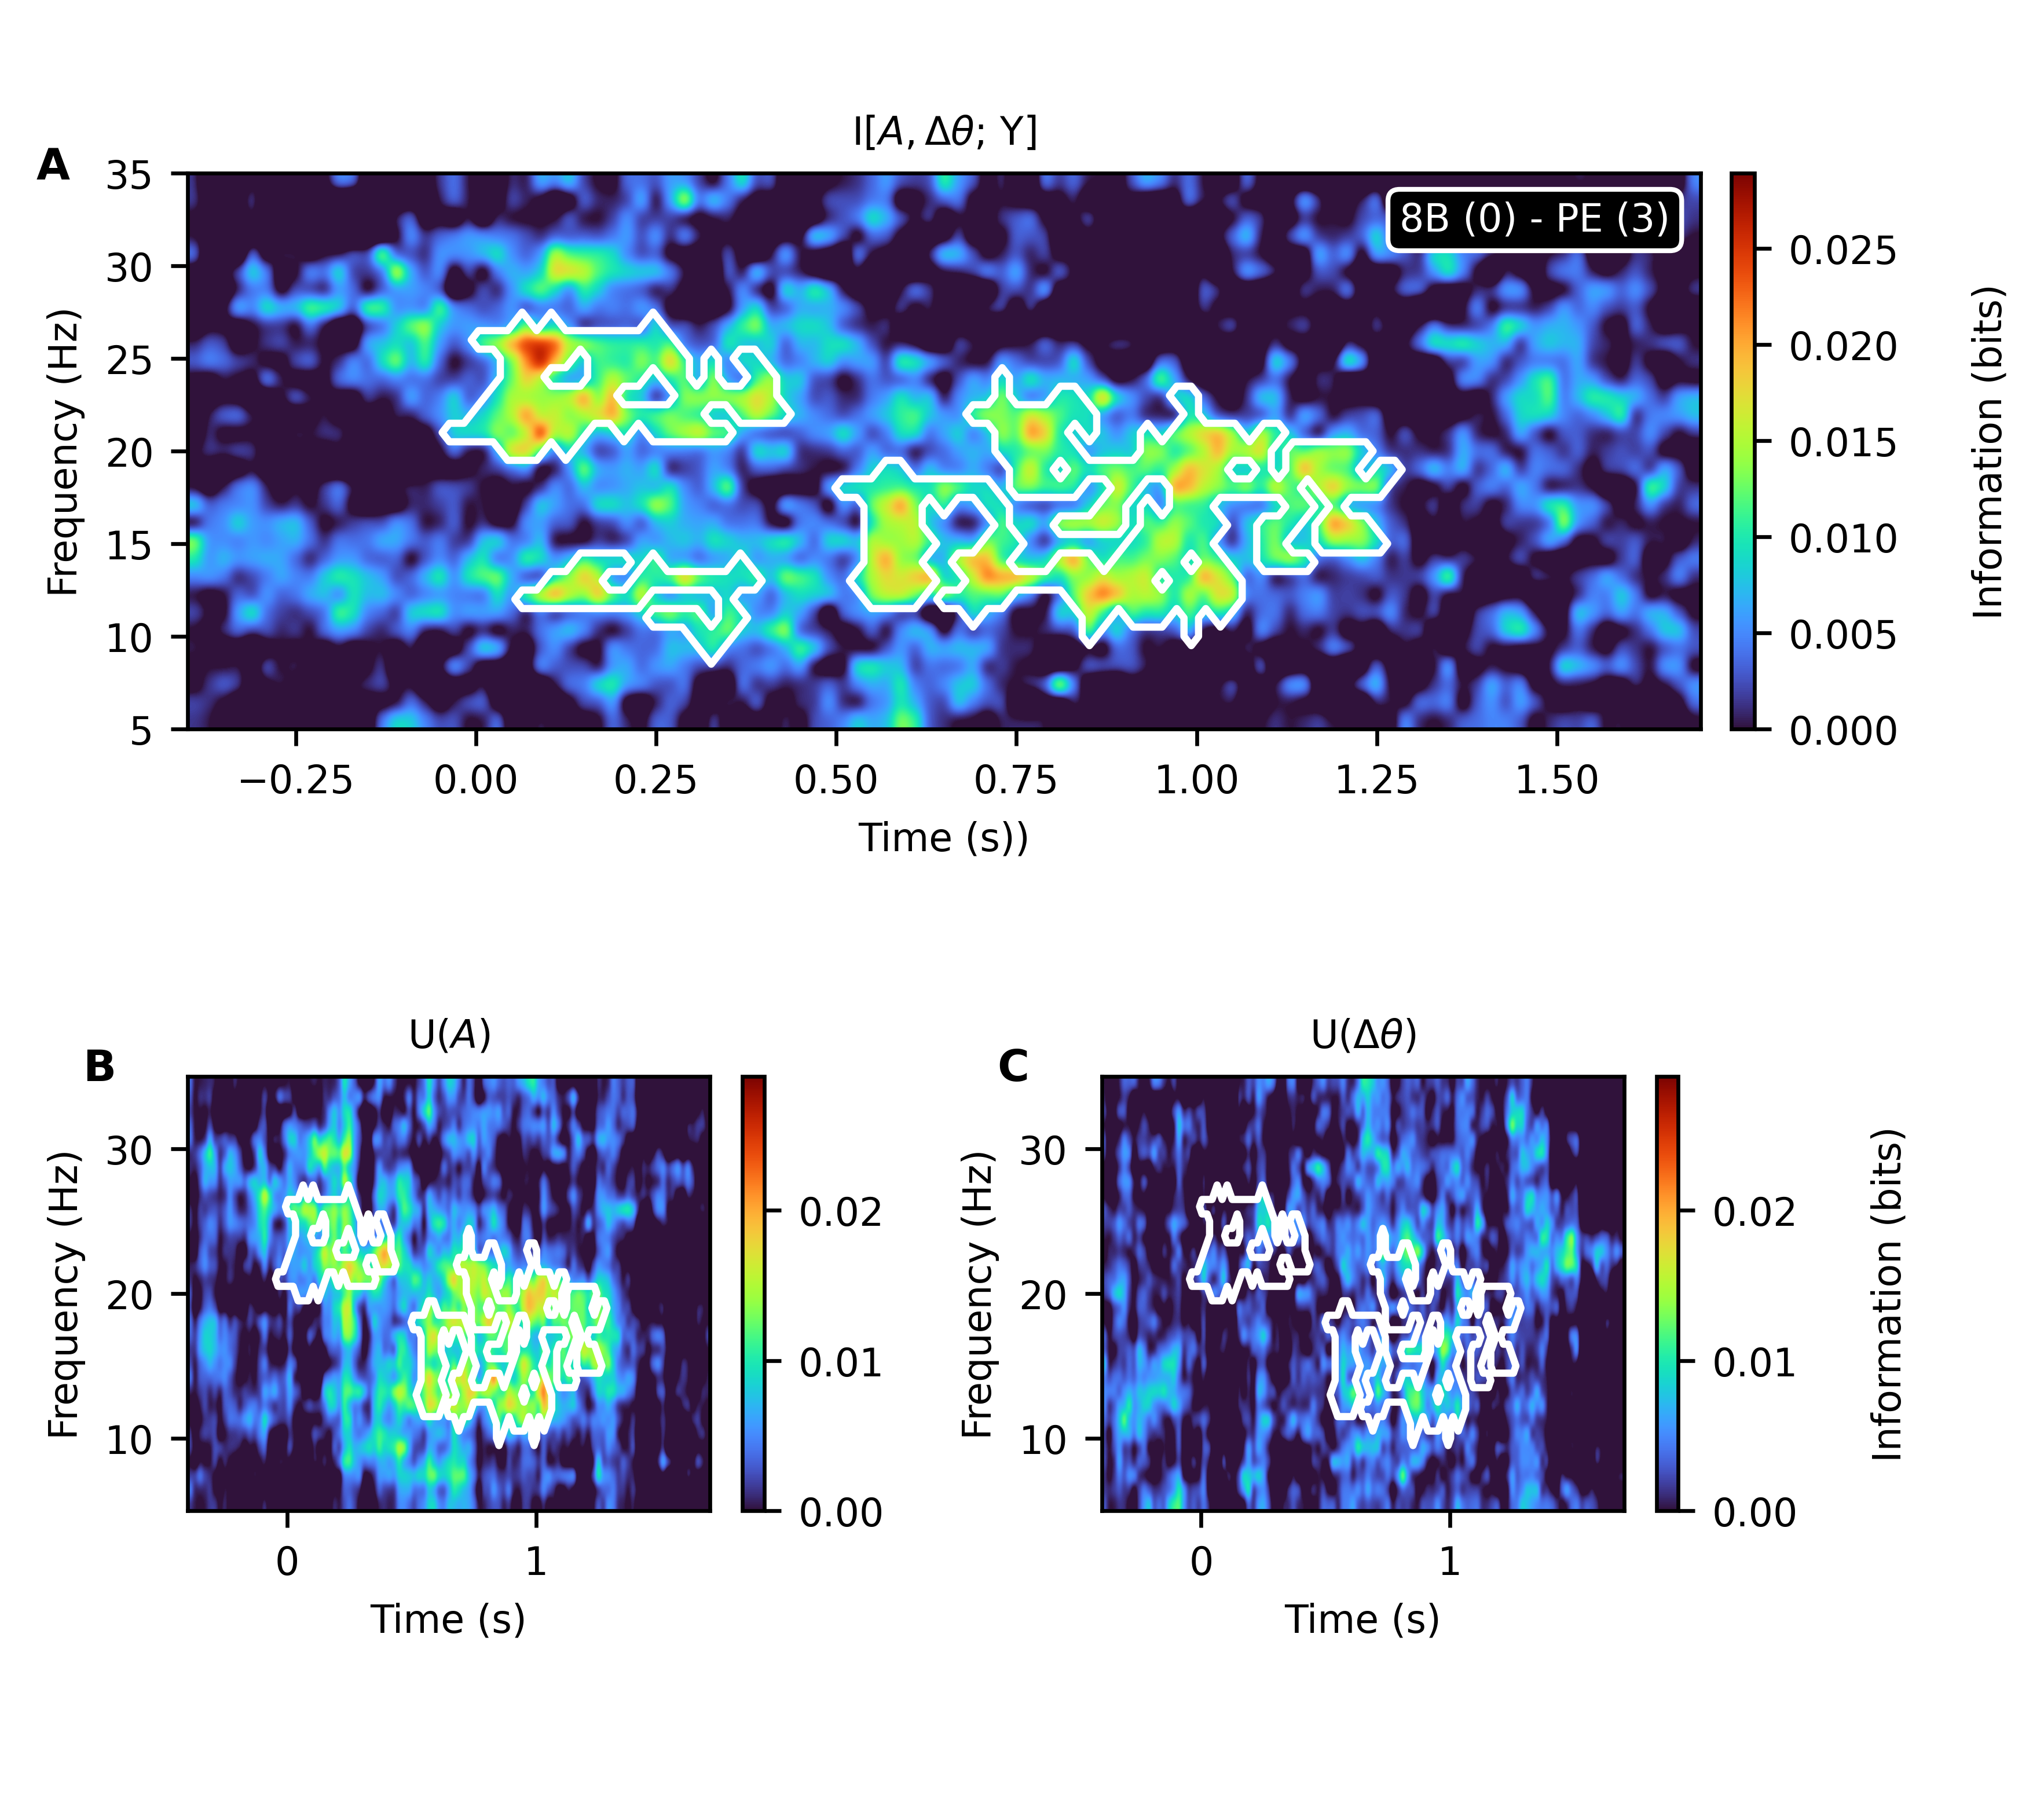

In [102]:
import plot
from PIL import Image

# ----------------------------------------------------------------------------
# Figure 6: joint MI and PID components for one fronto-parietal channel pair.
#   Panel A: I[A, dphi; stim] (top, full width)
#   Panel B: U(A)    = I[A; stim]    - red   (unique amplitude information)
#   Panel C: U(dphi) = I[dphi; stim] - red   (unique phase-difference info)
# ----------------------------------------------------------------------------

# Index of the (i, j) pair to plot in panel A. Index 2 corresponds to 8B-PE.
pos = 2

# Time axis bounds as plain Python floats. Passing xarray scalars to
# plt.contour's `extent=` triggers an array-wrap error inside matplotlib.
t_min, t_max = float(data.times.min()), float(data.times.max())

fig = plt.figure(figsize=(5.5, 5), dpi=600)

# Two row gridspecs:
#   gs1 = top row (Panel A image + thin colorbar), spanning the full width.
#   gs2 = bottom row (Panels B and C side by side).
gs1 = fig.add_gridspec(
    nrows=1,
    ncols=2,
    left=0.08,
    right=0.90,
    bottom=0.6,
    top=0.92,
    wspace=0.04,
    width_ratios=[0.97, 0.015],  # main image vs colorbar
)
gs2 = fig.add_gridspec(
    nrows=1, ncols=2, left=0.08, right=0.90, bottom=0.15, top=0.4, wspace=0.4
)

# Panel A axes (image + colorbar).
ax1 = plt.subplot(gs1[0])
ax1cb = plt.subplot(gs1[1])

# Panels B and C.
ax2 = plt.subplot(gs2[0])
ax3 = plt.subplot(gs2[1])


# --- Panel A: joint MI map -------------------------------------------------
plt.sca(ax1)
im = plt.imshow(
    I_S_R1_R2[pos],
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
    vmin=0,
    vmax=I_S_R1_R2.max() / 1.5,  # shared dynamic range across panels
    interpolation="gaussian",
)
# Bind the colorbar to the dedicated narrow axis on the right of Panel A.
cbar = plt.colorbar(im, cax=ax1cb)
cbar.set_label("Information (bits)", rotation=90, labelpad=15)

# Significance contour (cluster-corrected). NOTE: panel A uses 0.5 as the
# threshold (kept from the original figure spec); panels B/C use 0.05.
plt.contour(
    (p[..., pos].squeeze() <= 0.5).astype(float),
    levels=[0.5],
    colors="w",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
)

# Resolve ROI labels for the chosen pair to use in the text annotation.
i, j = x_s[pos], x_t[pos]

plt.title(r"I[$A, \Delta\theta$; Y]")
plt.xlabel("Time (s))")
plt.ylabel("Frequency (Hz)")

# Identify the channel pair with a plain text box (no marker line).
ax1.text(
    0.98, 0.95,
    f"{data.roi.values[i]} ({i}) - {data.roi.values[j]} ({j})",
    transform=ax1.transAxes,
    ha="right", va="top",
    fontsize=SMALL_SIZE,
    color="white",
    bbox=dict(facecolor="black", edgecolor="white", boxstyle="round,pad=0.3"),
)

# --- Panel B: unique information carried by amplitude ----------------------
plt.sca(ax2)
plt.imshow(
    (I_S_R1[pos] - red[pos]),
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
    vmin=0,
    vmax=I_S_R1_R2.max() / 1.5,
    interpolation="gaussian",
)
cbar = plt.colorbar()
plt.contour(
    (p[..., pos].squeeze() <= 0.05).astype(float),
    levels=[0.5],
    colors="w",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
)

plt.title(r"U($A$)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")

# --- Panel C: unique information carried by phase difference --------------
plt.sca(ax3)
plt.imshow(
    (I_S_R2[pos] - red[pos]),
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
    vmin=0,
    interpolation="gaussian",
    vmax=I_S_R1_R2.max() / 1.5,
)
cbar = plt.colorbar()

plt.title(r"U($\Delta\theta$)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
cbar.set_label("Information (bits)", rotation=90, labelpad=15)
plt.contour(
    (p[..., pos].squeeze() <= 0.05).astype(float),
    levels=[0.5],
    colors="w",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
)


# Hide the figure's outer background so the saved PDF has no visible frame.
bg = plot.Background(visible=False)

# Add A/B/C panel letters with a slight offset so they sit just outside each axis.
plot.add_panel_letters(
    fig,
    axes=[ax1, ax2, ax3],
    fontsize=MEDIUM_SIZE,
    xpos=[-0.1] + [-0.2] * 2,
    ypos=[0.99] * 3,
)

plt.savefig("../figures/Figure6.pdf")

### Figure 6 — Phase- and amplitude encoding in fronto-parietal recordings during working memory

The figure summarizes the *single-pair* analysis for the fronto-parietal pair
**8B - PE** (`pos = 2` in `x_s`/`x_t`).

- **Panel A.** *Stimulus-related coherence.* The full joint mutual
  information $I[A, \Delta\theta; Y]$ between the amplitude and
  phase-difference of the cross-spectrum and the stimulus label
  $Y$ (Eq. 3 in the paper). It quantifies how much the pair's
  joint phase/amplitude state distinguishes the presented stimulus,
  irrespective of whether that information lives in $A$, in
  $\Delta\theta$, or in their interaction.
- **Panel B.** *Unique amplitude information* $U(A) = I[A; Y] - R$,
  i.e. the amount of stimulus information that only $A$ provides
  (after removing what is also present in $\Delta\theta$).
- **Panel C.** *Unique phase-difference information*
  $U(\Delta\theta) = I[\Delta\theta; Y] - R$, the phase-only counterpart.

In all panels, the white contours delimit pixels that are significant
under a stimulus-label permutation null ($n = 1000$, $p < 0.05$,
cluster-mass corrected).

In [91]:
# Magnitude-squared coherence for two specific channel pairs:
#   coh1 : ROI 2 - ROI 3 (parietal-parietal: PG - PE)
#   coh2 : ROI 0 - ROI 3 (fronto-parietal:   8B - PE)
# Sxx, Syy are auto-spectra; Sxy is the cross-spectrum. Each is averaged over
# trials and tapers (axes 0 and 1 of W). Standard coherence formula: |Sxy|^2 / (Sxx*Syy).
i, j = 2, 3

Sxy = (W[:, i] * np.conj(W[:, j])).mean((0, 1))
Sxx = (W[:, i] * np.conj(W[:, i])).mean((0, 1))
Syy = (W[:, j] * np.conj(W[:, j])).mean((0, 1))

coh1 = np.abs(Sxy) ** 2 / (Sxx * Syy)

i, j = 0, 3

Sxy = (W[:, i] * np.conj(W[:, j])).mean((0, 1))
Sxx = (W[:, i] * np.conj(W[:, i])).mean((0, 1))
Syy = (W[:, j] * np.conj(W[:, j])).mean((0, 1))

coh2 = np.abs(Sxy) ** 2 / (Sxx * Syy)

In [92]:
# Build per-edge amplitude features for the higher-order analysis.
# For each pair we collapse the cross-spectrum to its modulus |z| (one feature
# per pair). The variable name `dphi*` is kept for historical reasons but the
# arrays now hold amplitude, not phase difference.
#
# Pair 1: ROI 0 - ROI 1
z = (W[:, 0] * np.conj(W[:, 1])).mean(1)  # average over tapers
dphi1 = np.abs(z)[None]  # shape (1, trials, freqs, times)

# Pair 2: ROI 2 - ROI 3
z = (W[:, 2] * np.conj(W[:, 3])).mean(1)
dphi2 = np.abs(z)[None]

# Stack the two edges along axis 0: this becomes the multivariate variable
# whose joint MI with the stimulus quantifies higher-order encoding.
mv = np.concatenate((dphi1, dphi2))

In [93]:
# Move the trial axis to the back to match what gcmi_model_nd_cd expects.
# After the transpose the layout is (mvaxis, freqs, times, trials).
dphi1 = dphi1.transpose(0, 2, 3, 1)
dphi2 = dphi2.transpose(0, 2, 3, 1)
mv = mv.transpose(0, 2, 3, 1)

In [94]:
# Higher-order MI estimates:
#   I_S_R1_hoi    : MI between edge-1 amplitude and stimulus.
#   I_S_R2_hoi    : MI between edge-2 amplitude and stimulus.
#   I_S_R1_R2_hoi : joint MI between (edge-1, edge-2) and stimulus.
# The PID of these three quantities yields redundant / synergistic information
# carried jointly by the two edges (computed in a later cell).
I_S_R1_hoi = gcmi_model_nd_cd(
    dphi1, np.asarray(data.trials.values), mvaxis=0, gcrn=True
)

I_S_R2_hoi = gcmi_model_nd_cd(
    dphi2, np.asarray(data.trials.values), mvaxis=0, gcrn=True
)

I_S_R1_R2_hoi = gcmi_model_nd_cd(
    mv, np.asarray(data.trials.values), mvaxis=0, gcrn=True
)

In [95]:
# Null distribution for the higher-order joint MI (edge-1 + edge-2 vs stimulus).
# Fewer permutations (200) than the lower-order analysis to keep runtime manageable.
I_S_R1_R2_hoi_shuffle = Parallel(n_jobs=5)(
    delayed(compute_shuffle)(mv) for n in tqdm(range(200))
)

100%|██████████| 200/200 [00:19<00:00, 10.34it/s]


In [96]:
# Cluster-corrected p-values for the higher-order joint MI map.
# Same WfStats setup as the lower-order analysis but on a single (edge-pair, freq, time) map.
p_hoi, t = wf.fit(
    [np.asarray(I_S_R1_R2_hoi[None])],
    [np.stack(I_S_R1_R2_hoi_shuffle)[:, None]],
    inference="ffx",
    mcp="cluster",
)

p_hoi = p_hoi.squeeze()

p_hoi.min()

    Fixed-effect inference (FFX)
    Cluster forming threshold (tail=1; alpha=0.05; tfce=None)
    Inference at cluster-level
    Cluster detection (threshold=0.009058416041299646; tail=1)


np.float64(0.005)

In [97]:
# PID of the higher-order MI:
#   red : redundant info shared between the two amplitude edges,
#   syn : synergistic info that exists only in the joint of the two edges.
# Note: this rebinds the names `red` and `syn` (previously the lower-order PID).
red = np.minimum(I_S_R1_hoi, I_S_R2_hoi)
syn = I_S_R1_R2_hoi - np.maximum(I_S_R2_hoi, I_S_R1_hoi)

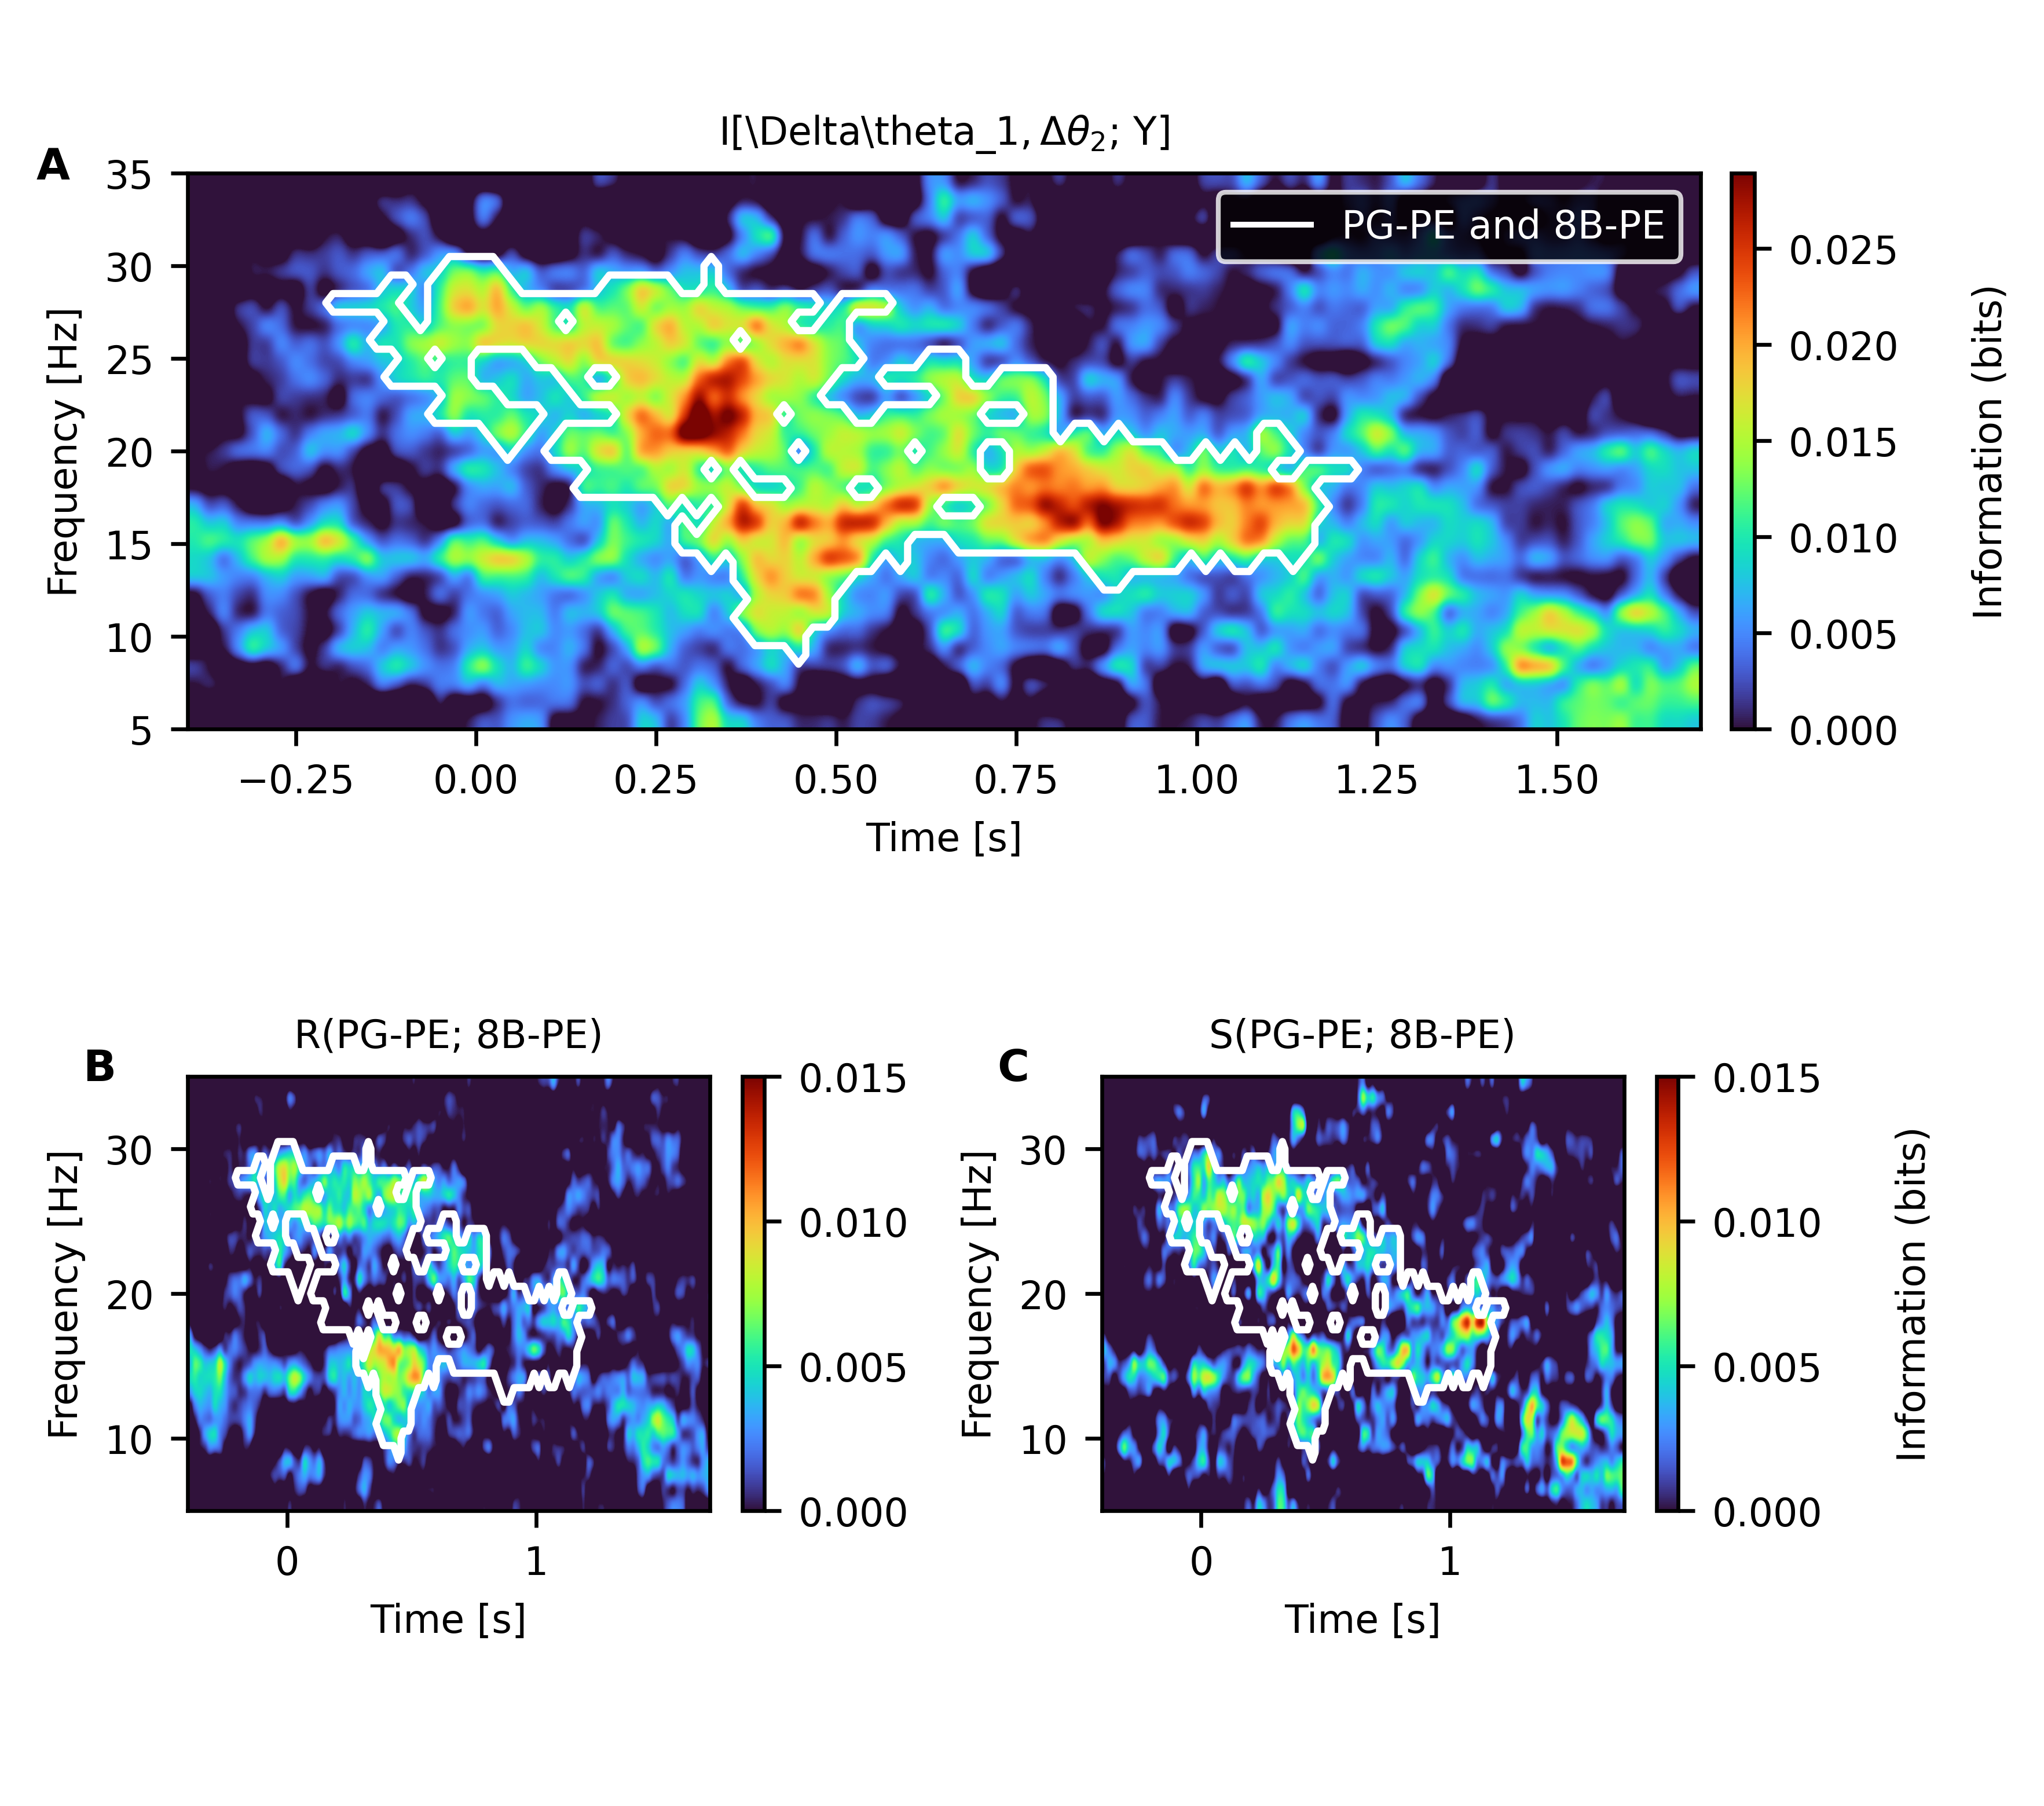

In [ ]:
import plot
from matplotlib.lines import Line2D
from PIL import Image

# ----------------------------------------------------------------------------
# Figure 7: higher-order joint MI and PID for the two-edge configuration
#   Panel A: I[edge1, edge2; stim] for the PG-PE / 8B-PE pair
#   Panel B: redundant info shared between the two edges
#   Panel C: synergistic info that only emerges from their joint
# Layout mirrors Figure 6 so the two figures read together.
# ----------------------------------------------------------------------------

# Time axis bounds as plain Python floats (avoids xarray + plt.contour pitfall).
t_min, t_max = float(data.times.min()), float(data.times.max())

fig = plt.figure(figsize=(5.5, 5), dpi=600)

# Top row: full-width Panel A (image + thin colorbar).
gs1 = fig.add_gridspec(
    nrows=1,
    ncols=2,
    left=0.08,
    right=0.90,
    bottom=0.6,
    top=0.92,
    wspace=0.04,
    width_ratios=[0.97, 0.015],
)
# Bottom row: side-by-side Panels B and C.
gs2 = fig.add_gridspec(
    nrows=1, ncols=2, left=0.08, right=0.90, bottom=0.15, top=0.4, wspace=0.4
)

# Panel A axes (image + colorbar).
ax1 = plt.subplot(gs1[0])
ax1cb = plt.subplot(gs1[1])

# Panels B and C.
ax2 = plt.subplot(gs2[0])
ax3 = plt.subplot(gs2[1])


# --- Panel A: joint higher-order MI map ------------------------------------
plt.sca(ax1)
im = plt.imshow(
    I_S_R1_R2_hoi,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
    vmin=0,
    vmax=I_S_R1_R2.max() / 1.5,  # share the dynamic range with Figure 6
    interpolation="gaussian",
)
cbar = plt.colorbar(im, cax=ax1cb)
cbar.set_label("Information (bits)", rotation=90, labelpad=15)

# Cluster-corrected significance contour (white outline).
plt.contour(
    (p_hoi.squeeze() <= 0.05).astype(float),
    levels=[0.5],
    colors="w",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
)

plt.title(r"I[\Delta\theta_1$, \Delta\theta_2$; Y]")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

# Identify the two edges shown so the legend doubles as the panel caption.
ax1.legend(
    handles=[Line2D([0], [0], color="w", lw=1.2, label=f"PG-PE and 8B-PE")],
    loc="upper right",
    frameon=True,
    facecolor="black",
    edgecolor="white",
    labelcolor="white",
    fontsize=SMALL_SIZE,
)

# Identify the channel pair with a plain text box (no marker line).
ax1.text(
    0.98, 0.95,
    f"{data.roi.values[i]} ({i}) - {data.roi.values[j]} ({j})",
    transform=ax1.transAxes,
    ha="right", va="top",
    fontsize=SMALL_SIZE,
    color="white",
    bbox=dict(facecolor="black", edgecolor="white", boxstyle="round,pad=0.3"),
)



# --- Panel B: redundant information between the two edges ------------------
plt.sca(ax2)
plt.imshow(
    red,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
    vmin=0,
    vmax=0.015,  # tighter dynamic range: PID components are small in absolute value
    interpolation="gaussian",
)
cbar = plt.colorbar()
plt.contour(
    (p_hoi.squeeze() <= 0.05).astype(float),
    levels=[0.5],
    colors="w",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
)

plt.title(r"R(PG-PE; 8B-PE)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

# --- Panel C: synergistic information unique to the joint ------------------
plt.sca(ax3)
plt.imshow(
    syn,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
    vmin=0,
    interpolation="gaussian",
    vmax=0.015,
)
cbar = plt.colorbar()

plt.title(r"S(PG-PE; 8B-PE)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

cbar.set_label("Information (bits)", rotation=90, labelpad=15)
plt.contour(
    (p_hoi.squeeze() <= 0.05).astype(float),
    levels=[0.5],
    colors="w",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
)


# Hide the figure's outer background so the saved PDF has no visible frame.
bg = plot.Background(visible=False)

# A/B/C panel letters slightly offset above-left of each axis.
plot.add_panel_letters(
    fig,
    axes=[ax1, ax2, ax3],
    fontsize=MEDIUM_SIZE,
    xpos=[-0.1] + [-0.2] * 2,
    ypos=[0.99] * 3,
)

plt.savefig("../figures/Figure7.pdf")

### Figure 7 — Higher-order phase- and amplitude encoding during working memory

The previous figure looked at one channel pair at a time. Here we ask a
**higher-order** question: do **two** channel pairs (or "edges")
*together* tell us more about the stimulus than either edge alone, and
if so, is that extra information *redundant* (the two edges carry the
same signal) or *synergistic* (the joint state matters in a way that
neither edge could reveal in isolation)?

We instantiate this by picking the parietal-parietal edge **PG-PE** and
the fronto-parietal edge **8B-PE**, taking the modulus of their
respective cross-spectra as the per-edge feature, and computing the
joint MI $I[\,\text{edge}_1, \text{edge}_2; Y\,]$ on top of the two
marginal MIs.

- **Panel A.** *Joint higher-order coherence* — total mutual information
  between the two edges' amplitudes and the stimulus (Eq. 3 in the paper;
  the per-edge amplitude feature is given by Eq. 10).
- **Panel B.** *Higher-order redundancy*
  $R = \min\big(I[\text{edge}_1;Y], I[\text{edge}_2;Y]\big)$ — the part
  of the stimulus information that is *shared* between the two edges.
- **Panel C.** *Higher-order synergy*
  $S = I[\text{edge}_1, \text{edge}_2;Y] - \max\big(I[\text{edge}_1;Y], I[\text{edge}_2;Y]\big)$ —
  the *additional* stimulus information that only emerges when the two
  edges are considered jointly.

White contours mark cluster-corrected significance ($p < 0.05$,
$n = 1000$ stimulus permutations).